# PPO_DRL (Reward Shaping)

In [1]:

import sys, os, time, math
import numpy as np

sys.path.insert(0, ".")

import shooter
import gymnasium as gym
from gymnasium import Wrapper
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

2026-05-10 20:10:27.503025: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# Reward Shaping

In [4]:
class ShooterRewardWrapper(Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_score = info["hunterScore"]
        self._kills = 0
        return obs, info

    def _aim_error(self, obs):
        yaw   = obs[3] * math.pi
        pitch = obs[4] * 0.9

        best = None
        best_dist = 1e9

        base = 6
        for i in range(15):
            j = base + i * 8
            alive = obs[j + 6] > 0.5
            if not alive:
                continue
            x = obs[j]     * 100.0
            z = obs[j + 1] * 100.0
            y = obs[j + 5] * 20.0
            dist = math.sqrt(x * x + z * z)
            if dist < best_dist:
                best_dist = dist
                best = (x, y, z)

        if best is None:
            return None

        x, y, z = best
        xz_dist = max(math.sqrt(x * x + z * z), 0.5)
        ideal_yaw   = math.atan2(z, x)
        ideal_pitch = math.atan2(y - 2.3, xz_dist)

        yaw_error = abs(yaw - ideal_yaw)
        if yaw_error > math.pi:
            yaw_error = 2 * math.pi - yaw_error

        pitch_error = abs(pitch - ideal_pitch)
        total_error = yaw_error + pitch_error
        return total_error

    def _aim_error_bonus(self, obs):
        # max 0.5 when error ~0
        err = self._aim_error(obs)
        if err is None:
            return 0.0
        bonus = max(0.0, 0.5 - (err * 0.6))
        return bonus

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        shaped = reward
        shaped -= 0.03                                    # time penalty (new)

        score_delta = info["hunterScore"] - self._prev_score
        if score_delta > 0:
            shaped += score_delta * 1.0                   # kill bonus (+20)
            self._kills += 1
        elif score_delta < 0:
            shaped += score_delta * 1.0                   # miss penalty (x1.0)

        if action in [2, 3, 4, 5]:
            shaped += 0.05                                # small move bonus

        shaped += self._aim_error_bonus(obs)              # aim-error bonus (max 0.5)

        
        aim_err = self._aim_error(obs)
        if action == 1 and aim_err is not None and aim_err < 0.20:
            shaped += 0.5

        self._prev_score = info["hunterScore"]
        info["kills"] = self._kills
        return obs, shaped, terminated, truncated, info

In [3]:
class DetailedLogCallback(BaseCallback):
    def __init__(self, log_every=100):
        super().__init__()
        self.log_every   = log_every
        self.ep_count    = 0
        self.cur_rewards = {}
        self.ep_rewards  = []
        self.ep_kills    = []
        self.ep_scores   = []
        self.start_time  = time.time()

    def _on_step(self):
        infos = self.locals.get("infos", [{}] * len(self.locals["dones"]))
        for i, done in enumerate(self.locals["dones"]):
            self.cur_rewards[i] = self.cur_rewards.get(i, 0) + self.locals["rewards"][i]
            if done:
                self.ep_count += 1
                self.ep_rewards.append(self.cur_rewards[i])
                self.ep_kills.append(infos[i].get("kills", 0))
                self.ep_scores.append(infos[i].get("hunterScore", 0))
                self.cur_rewards[i] = 0

                if self.ep_count % self.log_every == 0:
                    recent_r = self.ep_rewards[-self.log_every:]
                    recent_k = self.ep_kills[-self.log_every:]
                    recent_s = self.ep_scores[-self.log_every:]
                    elapsed  = time.time() - self.start_time
                    print(
                        f"Ep {self.ep_count:5d} | "
                        f"Mean: {np.mean(recent_r):7.2f} | "
                        f"Max: {np.max(recent_r):7.2f} | "
                        f"Min: {np.min(recent_r):7.2f} | "
                        f"Kill: {int(np.sum(recent_k)):4d} | "
                        f"Score: {np.mean(recent_s):6.1f} | "
                        f"Step {self.num_timesteps:7d} | "
                        f"Time: {elapsed/60:6.1f}m"
                    )
        return True

# Training

In [4]:
os.makedirs("models/PPO_v5", exist_ok=True)

print("\n" + "=" * 75)
print("  PPO + Reward Shaping v5  --  Shooter-v0")
print("  time -0.03 | kill bonus | miss x1.0 | aim max 0.5 | aim-shot +0.5")
print("=" * 75 + "\n")

def make_shaped_env():
    return ShooterRewardWrapper(gym.make("Shooter-v0", render_mode=None))

vec_env = make_vec_env(make_shaped_env, n_envs=8)

model = PPO(
    "MlpPolicy", vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=15,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.1,        # increased exploration
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=0,
    device="cuda",
)

print("Starting training...\n" + "=" * 75 + "\n")

model.learn(
    total_timesteps=3_000_000,
    callback=DetailedLogCallback(log_every=100),
    progress_bar=True,
)

model.save("models/PPO_v5/final")
vec_env.close()
print("\nTraining complete!  Saved to models/PPO_v5/final.zip\n")


  PPO + Reward Shaping v5  --  Shooter-v0
  time -0.03 | kill bonus | miss x1.0 | aim max 0.5 | aim-shot +0.5



Output()

/home/paradorn00/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Starting training...



Ep   100 | Mean: -215.39 | Max:  -87.77 | Min: -311.59 | Kill:   31 | Score:  -58.2 | Step   23816 | Time:    0.7m

...

Ep 12800 | Mean:  -69.67 | Max:   22.54 | Min: -136.90 | Kill:   66 | Score:    4.9 | Step 2932768 | Time:   71.9m

Ep 12900 | Mean:  -70.74 | Max:   10.01 | Min: -129.24 | Kill:   62 | Score:    3.4 | Step 2956376 | Time:   72.3m

Ep 13000 | Mean:  -62.82 | Max:   16.13 | Min: -138.14 | Kill:   76 | Score:    6.5 | Step 2978592 | Time:   72.7m

Ep 13100 | Mean:  -62.45 | Max:  -10.41 | Min: -127.00 | Kill:   79 | Score:    6.4 | Step 3002216 | Time:   73.3m


Training complete!  Saved to models/PPO_v5/final.zip



# Testing  

In [5]:
print("\n" + "=" * 75)
print("  Testing PPO_v5  --  30 episodes  (plain env)")
print("=" * 75 + "\n")

model  = PPO.load("models/PPO_v5/final")
env    = gym.make("Shooter-v0", render_mode=None)

def run_test(env, label):
    results, scores, kills_list, times_list = [], [], [], []
    for ep in range(30):
        obs, info   = env.reset()
        total_reward, steps, ep_kills = 0, 0, 0
        prev_score  = info["hunterScore"]
        ep_start    = time.time()

        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps        += 1

            score_delta = info["hunterScore"] - prev_score
            if score_delta > 0:
                ep_kills += 1
            prev_score = info["hunterScore"]

            if terminated or truncated:
                break

        ep_time = time.time() - ep_start
        results.append(total_reward)
        scores.append(info["hunterScore"])
        kills_list.append(ep_kills)
        times_list.append(ep_time)

        print(
            f"Ep {ep+1:2d} | "
            f"Reward: {total_reward:8.1f} | "
            f"Score: {info['hunterScore']:5d} | "
            f"Kill: {ep_kills:3d} | "
            f"Steps: {steps:4d} | "
            f"Time: {ep_time:.1f}s"
        )

    print(f"\n--- {label} Final Summary ---")
    print(f"Mean Reward : {np.mean(results):8.2f} +/- {np.std(results):.2f}")
    print(f"Max Reward  : {np.max(results):8.2f}")
    print(f"Mean Score  : {np.mean(scores):8.2f}")
    print(f"Max Score   : {int(np.max(scores)):8d}")
    print(f"Mean Kill   : {np.mean(kills_list):8.2f}")
    print(f"Total Kill  : {int(np.sum(kills_list)):8d}  (over 30 eps)")
    print(f"Mean Time   : {np.mean(times_list):8.2f}s per episode")
    print(f"Success Rate: {np.sum(np.array(scores) > 0) / len(scores) * 100:.1f}%")
    print("=" * 75 + "\n")

# ---- test 1: plain env ----
run_test(env, "Plain Env")
env.close()


  Testing PPO_v5  --  30 episodes  (plain env)

Ep  1 | Reward:   -114.3 | Score:    -4 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep  2 | Reward:    -96.3 | Score:    14 | Kill:   1 | Steps:  229 | Time: 0.2s
Ep  3 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep  4 | Reward:    -73.7 | Score:    36 | Kill:   2 | Steps:  229 | Time: 0.3s
Ep  5 | Reward:   -116.3 | Score:    -6 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep  6 | Reward:    -94.3 | Score:    16 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep  7 | Reward:   -110.1 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep  8 | Reward:   -114.3 | Score:    -4 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep  9 | Reward:   -106.3 | Score:     4 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep 10 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep 11 | Reward:   -118.3 | Score:    -8 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep 12 | Reward:    -94.3 | Score:    16 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep 

In [6]:
# ---- test 2: wrapper env ----
print("\n" + "=" * 75)
print("  Testing PPO_v5  --  30 episodes  (with reward shaping wrapper)")
print("=" * 75 + "\n")

wrapped_env = ShooterRewardWrapper(gym.make("Shooter-v0", render_mode=None))
run_test(wrapped_env, "Wrapper Env")
wrapped_env.close()


  Testing PPO_v5  --  30 episodes  (with reward shaping wrapper)

Ep  1 | Reward:    -48.5 | Score:    18 | Kill:   1 | Steps:  232 | Time: 0.4s
Ep  2 | Reward:    -90.1 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep  3 | Reward:    -65.7 | Score:    -4 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep  4 | Reward:     -0.0 | Score:    18 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep  5 | Reward:    -44.4 | Score:    14 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep  6 | Reward:    -28.2 | Score:     2 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep  7 | Reward:    -96.1 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.3s
Ep  8 | Reward:    -57.0 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.2s
Ep  9 | Reward:    -60.3 | Score:    16 | Kill:   1 | Steps:  229 | Time: 0.3s
Ep 10 | Reward:    -26.4 | Score:    18 | Kill:   1 | Steps:  229 | Time: 0.2s
Ep 11 | Reward:    -64.4 | Score:    10 | Kill:   1 | Steps:  229 | Time: 0.2s
Ep 12 | Reward:    -40.4 | Score:    18 | Kill:   1 | Steps:  22

# Parse PPO_V5 training log and plot training curve

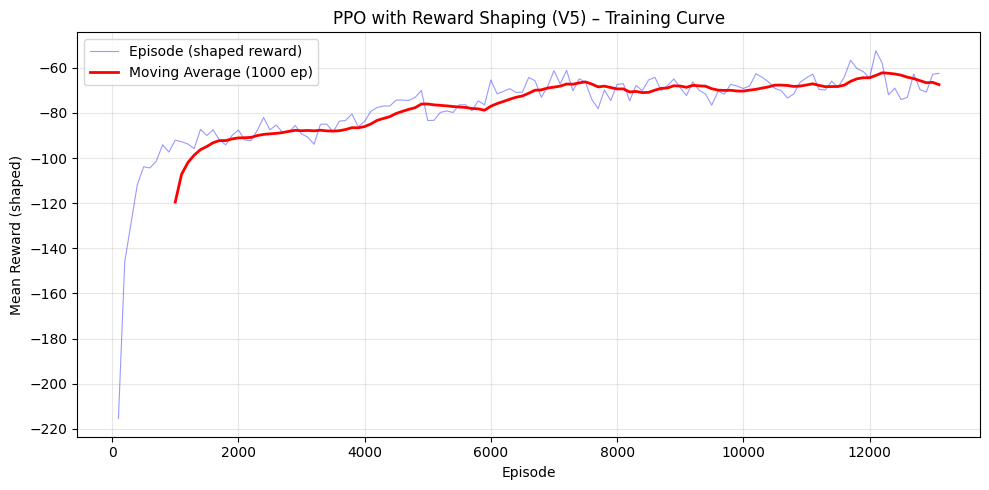

In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np


raw_text = """
Ep   100 | Mean: -215.39 | Max:  -87.77 | Min: -311.59 | Kill:   31 | Score:  -58.2 | Step   23816 | Time:    0.7m
Ep   200 | Mean: -145.97 | Max:  -75.44 | Min: -200.96 | Kill:   25 | Score:  -22.6 | Step   45816 | Time:    1.1m
Ep   300 | Mean: -128.84 | Max:  -45.89 | Min: -173.08 | Kill:   24 | Score:  -14.8 | Step   69616 | Time:    1.9m
Ep   400 | Mean: -111.68 | Max:  -55.06 | Min: -165.82 | Kill:   45 | Score:   -6.3 | Step   91672 | Time:    2.4m
Ep   500 | Mean: -103.88 | Max:  -12.46 | Min: -156.89 | Kill:   39 | Score:   -4.6 | Step  115424 | Time:    3.2m
Ep   600 | Mean: -104.37 | Max:  -24.24 | Min: -147.69 | Kill:   26 | Score:   -4.0 | Step  137472 | Time:    3.6m
Ep   700 | Mean: -101.35 | Max:  -32.19 | Min: -148.51 | Kill:   26 | Score:   -2.5 | Step  161232 | Time:    4.2m
Ep   800 | Mean:  -94.11 | Max:  -31.46 | Min: -132.92 | Kill:   35 | Score:    0.6 | Step  183280 | Time:    4.9m
Ep   900 | Mean:  -97.36 | Max:  -35.86 | Min: -134.89 | Kill:   25 | Score:   -1.1 | Step  207040 | Time:    5.3m
Ep  1000 | Mean:  -92.06 | Max:  -26.44 | Min: -127.84 | Kill:   25 | Score:    0.0 | Step  229080 | Time:    5.8m
Ep  1100 | Mean:  -92.76 | Max:  -41.52 | Min: -121.28 | Kill:   22 | Score:    0.3 | Step  252848 | Time:    6.6m
Ep  1200 | Mean:  -93.73 | Max:  -44.03 | Min: -123.83 | Kill:   14 | Score:   -0.6 | Step  274880 | Time:    7.0m
Ep  1300 | Mean:  -95.79 | Max:  -40.16 | Min: -119.85 | Kill:    8 | Score:   -1.3 | Step  298648 | Time:    7.8m
Ep  1400 | Mean:  -87.28 | Max:  -31.24 | Min: -119.68 | Kill:   21 | Score:    1.0 | Step  320688 | Time:    8.3m
Ep  1500 | Mean:  -89.97 | Max:   -5.62 | Min: -120.85 | Kill:   18 | Score:    0.0 | Step  344448 | Time:    9.1m
Ep  1600 | Mean:  -87.48 | Max:  -33.48 | Min: -142.96 | Kill:   33 | Score:    2.1 | Step  366488 | Time:    9.6m
Ep  1700 | Mean:  -91.99 | Max:  -31.20 | Min: -135.70 | Kill:   29 | Score:    0.7 | Step  390256 | Time:   10.1m
Ep  1800 | Mean:  -94.14 | Max:  -24.02 | Min: -130.39 | Kill:   23 | Score:   -0.4 | Step  412288 | Time:   10.8m
Ep  1900 | Mean:  -89.97 | Max:  -31.23 | Min: -139.01 | Kill:   24 | Score:    0.2 | Step  436072 | Time:   11.3m
Ep  2000 | Mean:  -87.56 | Max:  -32.42 | Min: -130.10 | Kill:   25 | Score:    1.3 | Step  458088 | Time:   11.7m
Ep  2100 | Mean:  -91.96 | Max:  -20.15 | Min: -131.11 | Kill:   19 | Score:    0.4 | Step  481872 | Time:   12.5m
Ep  2200 | Mean:  -92.26 | Max:  -17.41 | Min: -129.32 | Kill:   23 | Score:    0.8 | Step  503904 | Time:   12.9m
Ep  2300 | Mean:  -87.73 | Max:  -21.26 | Min: -124.94 | Kill:   18 | Score:    0.9 | Step  527672 | Time:   13.6m
Ep  2400 | Mean:  -82.03 | Max:   -5.28 | Min: -123.61 | Kill:   39 | Score:    4.5 | Step  549824 | Time:   14.1m
Ep  2500 | Mean:  -87.49 | Max:  -17.92 | Min: -134.15 | Kill:   26 | Score:    1.5 | Step  573488 | Time:   14.7m
Ep  2600 | Mean:  -85.36 | Max:  -23.40 | Min: -119.88 | Kill:   28 | Score:    2.6 | Step  595640 | Time:   15.2m
Ep  2700 | Mean:  -88.63 | Max:  -30.27 | Min: -117.92 | Kill:   15 | Score:    0.3 | Step  619288 | Time:   15.6m
Ep  2800 | Mean:  -88.55 | Max:    8.60 | Min: -127.78 | Kill:   28 | Score:    2.0 | Step  641440 | Time:   16.3m
Ep  2900 | Mean:  -85.53 | Max:  -13.02 | Min: -124.39 | Kill:   41 | Score:    4.3 | Step  665104 | Time:   16.7m
Ep  3000 | Mean:  -89.30 | Max:  -15.91 | Min: -127.23 | Kill:   21 | Score:    0.8 | Step  687240 | Time:   17.2m
Ep  3100 | Mean:  -90.72 | Max:  -26.39 | Min: -123.86 | Kill:   22 | Score:    0.4 | Step  710912 | Time:   17.8m
Ep  3200 | Mean:  -93.90 | Max:  -31.78 | Min: -131.10 | Kill:   13 | Score:   -1.9 | Step  733040 | Time:   18.2m
Ep  3300 | Mean:  -85.06 | Max:  -19.18 | Min: -124.76 | Kill:   25 | Score:    1.6 | Step  756728 | Time:   18.9m
Ep  3400 | Mean:  -84.92 | Max:  -22.45 | Min: -144.27 | Kill:   24 | Score:    1.4 | Step  778840 | Time:   19.2m
Ep  3500 | Mean:  -88.43 | Max:  -16.97 | Min: -124.72 | Kill:   19 | Score:    0.8 | Step  802544 | Time:   19.6m
Ep  3600 | Mean:  -83.69 | Max:  -11.28 | Min: -117.90 | Kill:   25 | Score:    1.5 | Step  824640 | Time:   20.2m
Ep  3700 | Mean:  -83.29 | Max:  -12.67 | Min: -124.90 | Kill:   31 | Score:    2.0 | Step  848344 | Time:   20.6m
Ep  3800 | Mean:  -80.47 | Max:  -10.38 | Min: -132.54 | Kill:   41 | Score:    3.3 | Step  870568 | Time:   21.3m
Ep  3900 | Mean:  -86.13 | Max:    3.20 | Min: -127.81 | Kill:   28 | Score:    1.0 | Step  894192 | Time:   21.7m
Ep  4000 | Mean:  -83.72 | Max:  -24.47 | Min: -122.08 | Kill:   33 | Score:    2.3 | Step  916368 | Time:   22.2m
Ep  4100 | Mean:  -79.28 | Max:  -22.16 | Min: -119.40 | Kill:   35 | Score:    2.5 | Step  939992 | Time:   22.8m
Ep  4200 | Mean:  -77.54 | Max:  -16.51 | Min: -121.36 | Kill:   42 | Score:    4.6 | Step  962176 | Time:   23.2m
Ep  4300 | Mean:  -76.91 | Max:  -15.44 | Min: -120.17 | Kill:   42 | Score:    4.6 | Step  985800 | Time:   23.9m
Ep  4400 | Mean:  -76.92 | Max:   -9.78 | Min: -132.31 | Kill:   37 | Score:    3.8 | Step 1007976 | Time:   24.3m
Ep  4500 | Mean:  -74.31 | Max:   -9.71 | Min: -120.55 | Kill:   42 | Score:    5.1 | Step 1031608 | Time:   24.7m
Ep  4600 | Mean:  -74.30 | Max:  -12.50 | Min: -126.91 | Kill:   44 | Score:    4.6 | Step 1053816 | Time:   25.4m
Ep  4700 | Mean:  -74.45 | Max:  -15.68 | Min: -120.66 | Kill:   42 | Score:    4.6 | Step 1077424 | Time:   25.8m
Ep  4800 | Mean:  -73.12 | Max:   -1.30 | Min: -120.26 | Kill:   43 | Score:    4.0 | Step 1099648 | Time:   26.6m
Ep  4900 | Mean:  -70.01 | Max:  -10.18 | Min: -126.01 | Kill:   50 | Score:    5.0 | Step 1123224 | Time:   27.1m
Ep  5000 | Mean:  -83.37 | Max:  -16.07 | Min: -139.71 | Kill:   38 | Score:    1.1 | Step 1145456 | Time:   27.5m
Ep  5100 | Mean:  -83.27 | Max:  -12.80 | Min: -133.14 | Kill:   44 | Score:    1.9 | Step 1169056 | Time:   28.3m
Ep  5200 | Mean:  -79.76 | Max:  -22.48 | Min: -133.82 | Kill:   48 | Score:    3.3 | Step 1191272 | Time:   28.7m
Ep  5300 | Mean:  -79.09 | Max:  -15.33 | Min: -142.74 | Kill:   60 | Score:    2.6 | Step 1214896 | Time:   29.5m
Ep  5400 | Mean:  -79.79 | Max:  -16.57 | Min: -160.57 | Kill:   47 | Score:    1.8 | Step 1237072 | Time:   29.9m
Ep  5500 | Mean:  -76.42 | Max:    0.68 | Min: -131.27 | Kill:   49 | Score:    3.3 | Step 1260704 | Time:   30.4m
Ep  5600 | Mean:  -76.35 | Max:   -5.56 | Min: -128.41 | Kill:   50 | Score:    3.4 | Step 1282872 | Time:   31.2m
Ep  5700 | Mean:  -79.03 | Max:    9.17 | Min: -134.51 | Kill:   40 | Score:    2.9 | Step 1306504 | Time:   31.6m
Ep  5800 | Mean:  -74.63 | Max:   -2.08 | Min: -123.92 | Kill:   47 | Score:    4.0 | Step 1328688 | Time:   32.3m
Ep  5900 | Mean:  -76.40 | Max:    0.12 | Min: -123.99 | Kill:   37 | Score:    2.3 | Step 1352304 | Time:   32.8m
Ep  6000 | Mean:  -65.40 | Max:    9.11 | Min: -128.27 | Kill:   53 | Score:    6.2 | Step 1374528 | Time:   33.2m
Ep  6100 | Mean:  -71.53 | Max:    1.15 | Min: -128.53 | Kill:   51 | Score:    5.3 | Step 1398136 | Time:   33.9m
Ep  6200 | Mean:  -70.44 | Max:   -4.62 | Min: -119.13 | Kill:   52 | Score:    5.7 | Step 1420360 | Time:   34.4m
Ep  6300 | Mean:  -69.25 | Max:   35.02 | Min: -126.30 | Kill:   56 | Score:    6.1 | Step 1443936 | Time:   35.2m
Ep  6400 | Mean:  -70.89 | Max:   -4.25 | Min: -131.74 | Kill:   59 | Score:    5.5 | Step 1466176 | Time:   35.7m
Ep  6500 | Mean:  -70.79 | Max:    3.83 | Min: -135.95 | Kill:   59 | Score:    5.1 | Step 1489768 | Time:   36.2m
Ep  6600 | Mean:  -64.27 | Max:    7.31 | Min: -128.66 | Kill:   65 | Score:    6.6 | Step 1511976 | Time:   36.8m
Ep  6700 | Mean:  -65.69 | Max:    0.32 | Min: -136.89 | Kill:   62 | Score:    7.0 | Step 1535584 | Time:   37.3m
Ep  6800 | Mean:  -73.03 | Max:   18.64 | Min: -133.70 | Kill:   57 | Score:    5.7 | Step 1557824 | Time:   38.1m
Ep  6900 | Mean:  -68.32 | Max:   -2.37 | Min: -129.88 | Kill:   62 | Score:    7.1 | Step 1581416 | Time:   38.5m
Ep  7000 | Mean:  -61.26 | Max:   -8.05 | Min: -132.13 | Kill:   70 | Score:    8.3 | Step 1603656 | Time:   38.9m
Ep  7100 | Mean:  -67.16 | Max:   26.84 | Min: -132.17 | Kill:   63 | Score:    6.5 | Step 1627232 | Time:   39.7m
Ep  7200 | Mean:  -61.05 | Max:   -4.62 | Min: -139.91 | Kill:   77 | Score:    8.9 | Step 1649496 | Time:   40.1m
Ep  7300 | Mean:  -70.21 | Max:   25.82 | Min: -141.85 | Kill:   65 | Score:    5.7 | Step 1673056 | Time:   40.9m
Ep  7400 | Mean:  -64.86 | Max:    2.38 | Min: -130.82 | Kill:   60 | Score:    6.5 | Step 1695336 | Time:   41.4m
Ep  7500 | Mean:  -66.44 | Max:   -0.99 | Min: -127.25 | Kill:   65 | Score:    6.4 | Step 1718888 | Time:   41.9m
Ep  7600 | Mean:  -73.99 | Max:   -4.43 | Min: -143.47 | Kill:   51 | Score:    3.1 | Step 1741152 | Time:   42.6m
Ep  7700 | Mean:  -78.08 | Max:   -2.38 | Min: -133.38 | Kill:   51 | Score:    3.8 | Step 1764720 | Time:   43.0m
Ep  7800 | Mean:  -69.87 | Max:    0.60 | Min: -126.43 | Kill:   51 | Score:    4.0 | Step 1786952 | Time:   43.8m
Ep  7900 | Mean:  -74.49 | Max:    4.39 | Min: -150.61 | Kill:   58 | Score:    4.9 | Step 1810520 | Time:   44.2m
Ep  8000 | Mean:  -67.37 | Max:   -0.15 | Min: -143.95 | Kill:   65 | Score:    5.7 | Step 1832784 | Time:   44.7m
Ep  8100 | Mean:  -67.02 | Max:   42.23 | Min: -130.28 | Kill:   64 | Score:    5.7 | Step 1856328 | Time:   45.4m
Ep  8200 | Mean:  -74.63 | Max:   -7.35 | Min: -143.44 | Kill:   54 | Score:    3.5 | Step 1878624 | Time:   45.9m
Ep  8300 | Mean:  -67.79 | Max:   -0.06 | Min: -148.00 | Kill:   68 | Score:    6.0 | Step 1902168 | Time:   46.7m
Ep  8400 | Mean:  -70.10 | Max:   -3.07 | Min: -155.14 | Kill:   66 | Score:    5.9 | Step 1924424 | Time:   47.2m
Ep  8500 | Mean:  -65.37 | Max:    1.69 | Min: -131.43 | Kill:   72 | Score:    7.4 | Step 1947992 | Time:   47.7m
Ep  8600 | Mean:  -64.19 | Max:    1.14 | Min: -132.83 | Kill:   70 | Score:    7.3 | Step 1970264 | Time:   48.4m
Ep  8700 | Mean:  -70.17 | Max:   31.81 | Min: -139.91 | Kill:   63 | Score:    5.8 | Step 1993808 | Time:   48.9m
Ep  8800 | Mean:  -67.90 | Max:   17.30 | Min: -131.86 | Kill:   68 | Score:    7.1 | Step 2016112 | Time:   49.6m
Ep  8900 | Mean:  -64.91 | Max:   21.73 | Min: -136.44 | Kill:   67 | Score:    6.9 | Step 2039632 | Time:   50.1m
Ep  9000 | Mean:  -68.79 | Max:   -6.36 | Min: -136.12 | Kill:   66 | Score:    6.3 | Step 2061928 | Time:   50.6m
Ep  9100 | Mean:  -72.31 | Max:   13.41 | Min: -135.53 | Kill:   62 | Score:    5.9 | Step 2085464 | Time:   51.3m
Ep  9200 | Mean:  -66.18 | Max:   31.98 | Min: -131.86 | Kill:   68 | Score:    6.5 | Step 2107776 | Time:   51.8m
Ep  9300 | Mean:  -69.95 | Max:   15.12 | Min: -128.53 | Kill:   63 | Score:    5.1 | Step 2131296 | Time:   52.5m
Ep  9400 | Mean:  -71.55 | Max:  -18.77 | Min: -132.31 | Kill:   58 | Score:    5.4 | Step 2153600 | Time:   53.0m
Ep  9500 | Mean:  -76.56 | Max:   -1.04 | Min: -130.52 | Kill:   52 | Score:    4.5 | Step 2177144 | Time:   53.4m
Ep  9600 | Mean:  -70.43 | Max:   -2.28 | Min: -122.08 | Kill:   53 | Score:    5.2 | Step 2199416 | Time:   54.1m
Ep  9700 | Mean:  -71.62 | Max:   -6.31 | Min: -141.63 | Kill:   51 | Score:    4.6 | Step 2222944 | Time:   54.6m
Ep  9800 | Mean:  -67.28 | Max:   -5.37 | Min: -122.03 | Kill:   56 | Score:    4.5 | Step 2245216 | Time:   55.3m
Ep  9900 | Mean:  -68.08 | Max:   -5.84 | Min: -139.98 | Kill:   64 | Score:    5.6 | Step 2268768 | Time:   55.7m
Ep 10000 | Mean:  -69.16 | Max:    2.82 | Min: -131.39 | Kill:   68 | Score:    5.5 | Step 2291016 | Time:   56.2m
Ep 10100 | Mean:  -68.03 | Max:   13.10 | Min: -133.80 | Kill:   59 | Score:    4.7 | Step 2314584 | Time:   57.0m
Ep 10200 | Mean:  -62.61 | Max:   -7.61 | Min: -126.36 | Kill:   67 | Score:    6.9 | Step 2336824 | Time:   57.4m
Ep 10300 | Mean:  -64.22 | Max:    8.50 | Min: -143.95 | Kill:   71 | Score:    6.9 | Step 2360424 | Time:   58.2m
Ep 10400 | Mean:  -66.25 | Max:   11.45 | Min: -141.79 | Kill:   76 | Score:    7.2 | Step 2382632 | Time:   58.6m
Ep 10500 | Mean:  -69.14 | Max:   12.96 | Min: -150.00 | Kill:   70 | Score:    4.3 | Step 2406264 | Time:   59.2m
Ep 10600 | Mean:  -70.08 | Max:   25.57 | Min: -140.13 | Kill:   65 | Score:    4.4 | Step 2428432 | Time:   59.9m
Ep 10700 | Mean:  -73.35 | Max:   -4.54 | Min: -132.32 | Kill:   62 | Score:    3.4 | Step 2452072 | Time:   60.4m
Ep 10800 | Mean:  -71.57 | Max:   -3.17 | Min: -160.07 | Kill:   59 | Score:    3.7 | Step 2474320 | Time:   61.1m
Ep 10900 | Mean:  -66.39 | Max:    8.10 | Min: -135.82 | Kill:   71 | Score:    5.9 | Step 2497880 | Time:   61.6m
Ep 11000 | Mean:  -64.46 | Max:   12.89 | Min: -140.37 | Kill:   73 | Score:    5.8 | Step 2520152 | Time:   62.1m
Ep 11100 | Mean:  -62.77 | Max:   10.87 | Min: -142.63 | Kill:   73 | Score:    5.3 | Step 2543736 | Time:   62.9m
Ep 11200 | Mean:  -69.60 | Max:    1.61 | Min: -141.17 | Kill:   64 | Score:    4.8 | Step 2565976 | Time:   63.3m
Ep 11300 | Mean:  -69.84 | Max:    9.49 | Min: -137.12 | Kill:   62 | Score:    3.3 | Step 2589560 | Time:   64.1m
Ep 11400 | Mean:  -65.91 | Max:    2.22 | Min: -138.83 | Kill:   67 | Score:    5.1 | Step 2611808 | Time:   64.6m
Ep 11500 | Mean:  -68.69 | Max:   29.59 | Min: -139.91 | Kill:   68 | Score:    4.6 | Step 2635384 | Time:   65.1m
Ep 11600 | Mean:  -64.07 | Max:    0.38 | Min: -146.48 | Kill:   75 | Score:    5.0 | Step 2657776 | Time:   65.7m
Ep 11700 | Mean:  -56.61 | Max:   11.90 | Min: -142.57 | Kill:   85 | Score:    9.1 | Step 2681232 | Time:   66.1m
Ep 11800 | Mean:  -60.33 | Max:   26.65 | Min: -141.93 | Kill:   81 | Score:    6.9 | Step 2703704 | Time:   66.8m
Ep 11900 | Mean:  -61.63 | Max:   -2.62 | Min: -144.06 | Kill:   84 | Score:    7.8 | Step 2727176 | Time:   67.2m
Ep 12000 | Mean:  -64.56 | Max:   43.48 | Min: -147.77 | Kill:   74 | Score:    5.0 | Step 2749504 | Time:   67.5m
Ep 12100 | Mean:  -52.41 | Max:   13.35 | Min: -132.28 | Kill:   90 | Score:    9.7 | Step 2772984 | Time:   68.2m
Ep 12200 | Mean:  -57.89 | Max:   15.03 | Min: -141.22 | Kill:   80 | Score:    7.7 | Step 2795304 | Time:   68.6m
Ep 12300 | Mean:  -71.96 | Max:    3.21 | Min: -155.14 | Kill:   65 | Score:    3.2 | Step 2818800 | Time:   69.3m
Ep 12400 | Mean:  -69.02 | Max:   17.56 | Min: -132.83 | Kill:   69 | Score:    5.5 | Step 2841144 | Time:   69.7m
Ep 12500 | Mean:  -74.09 | Max:   -9.54 | Min: -146.25 | Kill:   60 | Score:    2.8 | Step 2864704 | Time:   70.1m
Ep 12600 | Mean:  -73.04 | Max:    3.90 | Min: -160.08 | Kill:   59 | Score:    1.8 | Step 2886952 | Time:   70.8m
Ep 12700 | Mean:  -62.71 | Max:   23.18 | Min: -130.79 | Kill:   73 | Score:    6.4 | Step 2910560 | Time:   71.2m
Ep 12800 | Mean:  -69.67 | Max:   22.54 | Min: -136.90 | Kill:   66 | Score:    4.9 | Step 2932768 | Time:   71.9m
Ep 12900 | Mean:  -70.74 | Max:   10.01 | Min: -129.24 | Kill:   62 | Score:    3.4 | Step 2956376 | Time:   72.3m
Ep 13000 | Mean:  -62.82 | Max:   16.13 | Min: -138.14 | Kill:   76 | Score:    6.5 | Step 2978592 | Time:   72.7m
Ep 13100 | Mean:  -62.45 | Max:  -10.41 | Min: -127.00 | Kill:   79 | Score:    6.4 | Step 3002216 | Time:   73.3m
"""

# Parse the log
pattern = r"Ep\s+(\d+)\s+\|\s+Mean:\s+([-\d.]+)\s+"
matches = re.findall(pattern, raw_text)

episodes = []
mean_rewards = []
for ep_str, mean_str in matches:
    episodes.append(int(ep_str))
    mean_rewards.append(float(mean_str))

# Convert to numpy arrays
episodes = np.array(episodes)
mean_rewards = np.array(mean_rewards)

# Create training curve plot
plt.figure(figsize=(10, 5))
plt.plot(episodes, mean_rewards, alpha=0.4, linewidth=0.8, color='blue', label='Episode (shaped reward)')

# Moving average (window = 10, i.e., 1000 episodes)
window = 10
if len(mean_rewards) >= window:
    ma = np.convolve(mean_rewards, np.ones(window)/window, mode='valid')
    plt.plot(episodes[window-1:], ma, color='red', linewidth=2, label=f'Moving Average ({window*100} ep)')

plt.xlabel('Episode')
plt.ylabel('Mean Reward (shaped)')
plt.title('PPO with Reward Shaping (V5) – Training Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('ppo_v5_training_curve.png', dpi=150)
plt.show()

# Final evaluation: 10 episodes & best‑episode video 

In [2]:
# =============================================================
# Cell: PPO_V5 Evaluation (10 episodes + TensorBoard + Video)
# =============================================================
import time
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from torch.utils.tensorboard import SummaryWriter
from gymnasium.wrappers import RecordVideo

MODEL_PATH = "models/PPO_v5/final"
LOG_DIR    = "runs/PPO_v5_eval"
VIDEO_DIR  = "videos/PPO_v5_best"
NUM_EPS    = 10

model = PPO.load(MODEL_PATH)
writer = SummaryWriter(LOG_DIR)

# Phase 1 – evaluate with fixed seeds, store seed for each episode
results = []          # (total_reward, final_score, kills, steps, seed)
print(f"Evaluating PPO_V5 – {NUM_EPS} episodes …\n")
for ep in range(NUM_EPS):
    ep_seed = 2000 + ep          # fixed seed so we can reproduce later
    env = gym.make("Shooter-v0", render_mode=None)
    obs, info = env.reset(seed=ep_seed)
    total_reward, ep_kills = 0.0, 0
    prev_score = info["hunterScore"]

    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        score_delta = info["hunterScore"] - prev_score
        if score_delta > 0:
            ep_kills += 1
        prev_score = info["hunterScore"]
        if terminated or truncated:
            break
    env.close()

    final_score = info["hunterScore"]
    steps = info["tick"]
    results.append((total_reward, final_score, ep_kills, steps, ep_seed))

    # Log each episode to TensorBoard
    writer.add_scalar("Episode/Reward", total_reward, ep)
    writer.add_scalar("Episode/Score",  final_score,  ep)
    writer.add_scalar("Episode/Kills",  ep_kills,     ep)
    writer.add_scalar("Episode/Steps",  steps,        ep)

# Convert to numpy arrays for analysis
arr_rewards = np.array([r[0] for r in results])
arr_scores  = np.array([r[1] for r in results])
arr_kills   = np.array([r[2] for r in results])
arr_steps   = np.array([r[3] for r in results])

best_reward_idx = np.argmax(arr_rewards)
best_score_idx  = np.argmax(arr_scores)
best_kill_idx   = np.argmax(arr_kills)

# Print summary table
print("─" * 60)
print(f"{'Ep':>4s} | {'Reward':>10s} | {'Score':>6s} | {'Kills':>5s} | {'Steps':>5s} | {'Seed':>5s}")
print("─" * 60)
for i in range(NUM_EPS):
    print(f"{i+1:4d} | {arr_rewards[i]:10.2f} | {arr_scores[i]:6d} | {arr_kills[i]:5d} | {arr_steps[i]:5d} | {results[i][4]:5d}")
print("─" * 60)
print(f"Best Reward : episode {best_reward_idx+1:2d}  with reward = {arr_rewards[best_reward_idx]:.2f}  (seed {results[best_reward_idx][4]})")
print(f"Best Score  : episode {best_score_idx+1:2d}  with score  = {arr_scores[best_score_idx]}  (seed {results[best_score_idx][4]})")
print(f"Best Kills  : episode {best_kill_idx+1:2d}  with kills  = {arr_kills[best_kill_idx]}  (seed {results[best_kill_idx][4]})")
print("─" * 60)

# Log overall summary scalars
writer.add_scalar("Summary/Mean_Reward", np.mean(arr_rewards))
writer.add_scalar("Summary/Std_Reward",  np.std(arr_rewards))
writer.add_scalar("Summary/Mean_Score",  np.mean(arr_scores))
writer.add_scalar("Summary/Mean_Kills",  np.mean(arr_kills))

# Phase 2 – record the exact episode with the BEST SCORE (not reward)
chosen_ep = best_score_idx               # ← changed to best score
best_seed = results[chosen_ep][4]
print(f"\nRecording episode {chosen_ep+1} (best score) with seed={best_seed} (score will be {arr_scores[chosen_ep]}) …")

# Create a fresh environment with the RecordVideo wrapper
env = gym.make("Shooter-v0", render_mode="rgb_array")
env = RecordVideo(
    env, VIDEO_DIR,
    episode_trigger=lambda ep_id: ep_id == 0   # record the very first episode
)
obs, info = env.reset(seed=best_seed)          # same seed as Phase 1 ⇒ identical episode

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
env.close()

writer.close()
print(f"\nVideo saved in '{VIDEO_DIR}'.")
print(f"Run `tensorboard --logdir runs` to view logs.")

/home/paradorn00/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Evaluating PPO_V5 – 10 episodes …

────────────────────────────────────────────────────────────
  Ep |     Reward |  Score | Kills | Steps |  Seed
────────────────────────────────────────────────────────────
   1 |    -110.31 |      0 |     0 |   229 |  2000
   2 |     -74.24 |     36 |     2 |   229 |  2001
   3 |    -110.31 |      0 |     0 |   229 |  2002
   4 |     -94.29 |     16 |     1 |   229 |  2003
   5 |     -92.10 |     18 |     1 |   229 |  2004
   6 |     -94.27 |     16 |     1 |   229 |  2005
   7 |     -92.78 |     18 |     1 |   231 |  2006
   8 |     -98.34 |     12 |     1 |   230 |  2007
   9 |    -112.30 |     -2 |     0 |   229 |  2008
  10 |     -94.30 |     16 |     1 |   229 |  2009
────────────────────────────────────────────────────────────
Best Reward : episode  2  with reward = -74.24  (seed 2001)
Best Score  : episode  2  with score  = 36  (seed 2001)
Best Kills  : episode  2  with kills  = 2  (seed 2001)
──────────────────────────────────────────────────

/home/paradorn00/miniconda3/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /mnt/c/Users/lenovo/Desktop/FOR AIT HOMEWORK/2_Y1 SEM 2/Deep learning/Final Project/project/videos/PPO_v5_best folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Video saved in 'videos/PPO_v5_best'.
Run `tensorboard --logdir runs` to view logs.


In [ ]:
!tensorboard --logdir runs

/home/paradorn00/miniconda3/lib/python3.13/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6007/ (Press CTRL+C to quit)
